# Programming Assignment 2

---

- delete before submitting!

- To manage the done tasks, I added some chechboxes like this:

&#9744; Task not done

&#9745; Task done

---

In [1]:
import csv
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import scipy.sparse as sp
from sklearn.metrics import roc_auc_score

In [2]:
def load_toy_dataset_csv(file_path):
    X = []
    y = []
    
    with open(file_path, mode='r',encoding='utf-8') as f:
        reader = csv.reader(f)
        
        header = next(reader) 
        
        for row in reader:

            float_row = [float(val) for val in row]
            X.append(float_row[:-1])
            label = float_row[-1]
            y.append(1.0 if label == 1 else -1.0)
            
    return np.array(X), np.array(y)

In [3]:
X_toy_t, y_toy_t = load_toy_dataset_csv(r'datasets/toydata_tiny.csv')

In [4]:
X_toy_l, y_toy_l = load_toy_dataset_csv(r'datasets/toydata_large.csv')

## Linear SVM with SGD Variants (25%)

For all datasets except IMDB and Higgs, use 5-fold cross validation for computing performances, and use classification accuracy as measure of prediction performance.

In [5]:
def get_folds(X, y, k=5):
    indices = np.arange(len(y))
    np.random.shuffle(indices) 
    
    fold_sizes = np.full(k, len(y) // k)
    fold_sizes[:len(y) % k] += 1
    current = 0
    folds = []
    for size in fold_sizes:
        start, stop = current, current + size
        folds.append(indices[start:stop])
        current = stop
    return folds

def cross_validation(model_class, X, y, k=5, **model_params):
    folds = get_folds(X, y, k)
    scores = []
    
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
        
        model = model_class(**model_params)
        model.train(X_train, y_train)
        
        preds = model.predict(X_test)
        accuracy = np.mean(preds == y_test)
        scores.append(accuracy)
        
    return np.mean(scores), np.std(scores)

&#9745; SVM with optimization methods (standard SGD, momentum and Adagrad).

In [6]:
class LargeScaleSVM:
    def __init__(self, optimizer='sgd', learning_rate=0.01, lambda_reg=0.01, batch_size=32, momentum=0.9):
        self.optimizer = optimizer
        self.lr = learning_rate
        self.lambda_reg = lambda_reg
        self.batch_size = batch_size
        self.momentum_param = momentum
        self.w = None
        self.history = []

    def train(self, X, y, epochs=10):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        v = np.zeros(n_features)
        G = np.zeros(n_features)
        eps = 1e-8
        self.history = []
        y = np.asarray(y).flatten()

        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            for i in range(0, n_samples, self.batch_size):
                batch_idx = indices[i : i + self.batch_size]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                
                grad = self.lambda_reg * self.w
                margins = y_batch * (X_batch.dot(self.w))
                mis_idx = np.where(margins < 1)[0]
                
                if len(mis_idx) > 0:
                    for idx in mis_idx:
                        xi = X_batch[idx]
                        yi = y_batch[idx]
                        
                        if hasattr(xi, "toarray"):
                            grad -= (yi * xi.toarray().flatten()) / self.batch_size
                        else:
                            grad -= (yi * xi) / self.batch_size
                
                
                if self.optimizer == 'sgd':
                    self.w -= self.lr * grad
                elif self.optimizer == 'momentum':
                    v = self.momentum_param * v + self.lr * grad
                    self.w -= v
                elif self.optimizer == 'adagrad':
                    G += grad**2
                    self.w -= (self.lr / (np.sqrt(G) + eps)) * grad
            
            self.history.append(self.calculate_loss(X, y))    
            

    def predict(self, X):
        return np.sign(X.dot(self.w))

    def calculate_loss(self, X, y):
        margins = y * (X.dot(self.w))
        hinge_loss = np.mean(np.maximum(0, 1 - margins))
        reg_loss = 0.5 * self.lambda_reg * np.dot(self.w, self.w)
        return hinge_loss + reg_loss

### Toydata_Tiny dataset - classification accuracy/AUC and runtime

&#9745; Accuracy and runtime for the Toydata_Tiny dataset

In [7]:
for opt in ['sgd', 'momentum', 'adagrad']:
    start_time = time.time()
    
    mean_acc, std_acc = cross_validation(
        LargeScaleSVM, 
        X_toy_t, 
        y_toy_t, 
        k=5, 
        optimizer=opt, 
        batch_size=32
    )
    
    duration = time.time() - start_time
    print(f"Result: {opt.upper()} -> Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f}), Time: {duration:.2f}s")

Result: SGD -> Accuracy: 0.8100 (+/- 0.0464), Time: 0.04s
Result: MOMENTUM -> Accuracy: 0.9250 (+/- 0.0274), Time: 0.02s
Result: ADAGRAD -> Accuracy: 0.5000 (+/- 0.0316), Time: 0.04s


### Toydata_Large dataset - classification accuracy/AUC and runtime

&#9745; Accuracy and runtime for the Toydata_Large dataset

In [8]:
for opt in ['sgd', 'momentum', 'adagrad']:
    start_time = time.time()
    
    mean_acc, std_acc = cross_validation(
        LargeScaleSVM, 
        X_toy_l, 
        y_toy_l, 
        k=5, 
        optimizer=opt, 
        batch_size=32
    )
    
    duration = time.time() - start_time
    print(f"Result: {opt.upper()} -> Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f}), Time: {duration:.2f}s")

Result: SGD -> Accuracy: 1.0000 (+/- 0.0000), Time: 4.16s
Result: MOMENTUM -> Accuracy: 0.9997 (+/- 0.0006), Time: 4.72s
Result: ADAGRAD -> Accuracy: 1.0000 (+/- 0.0000), Time: 5.88s


### IMDB dataset - classification accuracy/AUC and runtime

&#9745; Accuracy and runtime for the IMDB dataset

In [9]:
def load_imdb(file_path):
    data = np.load(file_path, allow_pickle=True)
    
    X_train = data['train'].item()
    y_train = data['train_labels']
    X_test = data['test'].item()
    y_test = data['test_labels']
    
    y_train = np.where(y_train == 0, -1, 1)
    y_test = np.where(y_test == 0, -1, 1)
    
    return X_train, y_train, X_test, y_test

X_train_imdb, y_train_imdb, X_test_imdb, y_test_imdb = load_imdb(r'datasets/imdb.npz')

In [10]:
for opt in ['sgd', 'momentum', 'adagrad']:
    start_time = time.time()
    
    model = LargeScaleSVM(optimizer=opt, learning_rate=0.001, batch_size=64)
    model.train(X_train_imdb, y_train_imdb, epochs=10)
    
    preds = model.predict(X_test_imdb)
    acc = np.mean(preds == y_test_imdb)
    
    scores = X_test_imdb.dot(model.w)
    auc = roc_auc_score(y_test_imdb, scores)
    
    duration = time.time() - start_time
    print(f"{opt.upper()}: Accuracy = {acc:.4f}, AUC = {auc:.4f}, Time = {duration:.2f}s")

SGD: Accuracy = 0.4998, AUC = 0.7373, Time = 43.12s
MOMENTUM: Accuracy = 0.4998, AUC = 0.7372, Time = 38.18s
ADAGRAD: Accuracy = 0.5015, AUC = 0.8449, Time = 38.54s


### Higgs Dataset - classification accuracy/AUC and runtime

&#9745; Accuracy and runtime for the Higgs dataset

In [11]:
def load_higgs(file_path):
    data = np.load(file_path)
    
    X_train = data['train']
    y_train = data['train_labels']
    X_test = data['test']
    y_test = data['test_labels']
    
    y_train = np.where(y_train == 0, -1, 1)
    y_test = np.where(y_test == 0, -1, 1)
    
    return X_train, y_train, X_test, y_test

X_train_higgs, y_train_higgs, X_test_higgs, y_test_higgs = load_higgs(r'datasets/higgs.npz')

In [12]:
for opt in ['sgd', 'momentum', 'adagrad']:
    start_time = time.time()
    
    model = LargeScaleSVM(optimizer=opt, learning_rate=0.001, batch_size=128)
    model.train(X_train_higgs, y_train_higgs, epochs=10)
    
    preds = model.predict(X_test_higgs)
    acc = np.mean(preds == y_test_higgs)
    
    scores = X_test_higgs.dot(model.w)
    auc = roc_auc_score(y_test_higgs, scores)
    
    duration = time.time() - start_time
    print(f"{opt.upper()}: Accuracy = {acc:.4f}, AUC = {auc:.4f}, Time = {duration:.2f}s")

SGD: Accuracy = 0.6227, AUC = 0.6639, Time = 298.51s
MOMENTUM: Accuracy = 0.6205, AUC = 0.6641, Time = 315.77s
ADAGRAD: Accuracy = 0.5848, AUC = 0.6332, Time = 343.67s


### TODO

&#9744; Report how you selected the learning rate, learning rate schedule, batch size, and regularization parameter. Did you use different parameters for different datasets or optimizer variants?

### Convergence plots for the optimizers (training loss vs. number of passes/epochs).

&#9745; Include convergence plots for the optimizers (training loss vs. number of passes/epochs).

In [13]:
def plot_convergence(X, y, optimizers=['sgd', 'momentum', 'adagrad']):
    plt.figure(figsize=(10, 4))
    for opt in optimizers:
        
        model = LargeScaleSVM(optimizer=opt, learning_rate=0.01, batch_size=32)
        model.train(X, y, epochs=50) 
        plt.plot(model.history, label=f'Optimizer: {opt.upper()}')
    
    plt.title('Convergence Plots: Training Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Hinge Loss + L2')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Plot for Toydata_tiny dataset

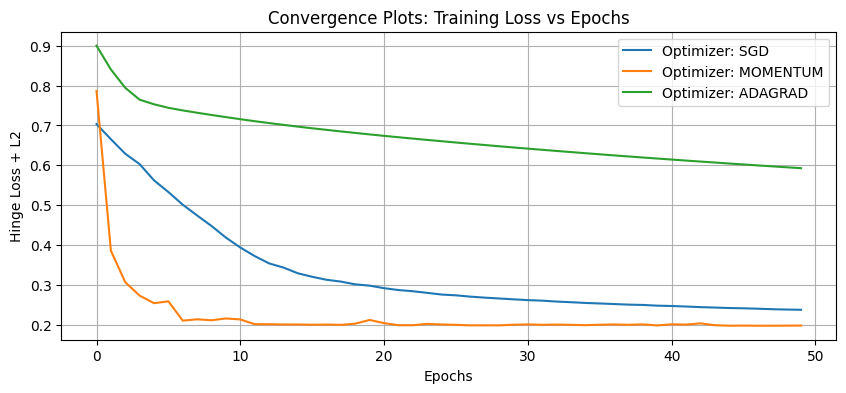

In [14]:
plot_convergence(X_toy_t, y_toy_t)

#### Plot for Toydata_large dataset

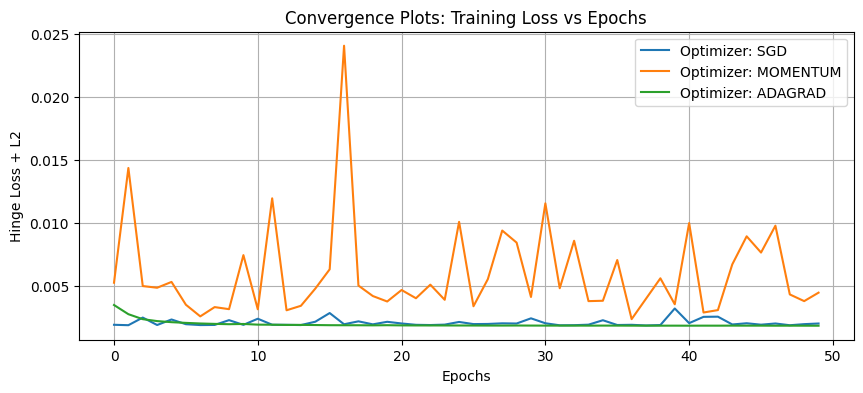

In [15]:
plot_convergence(X_toy_l, y_toy_l)

#### Plot for IMDB dataset

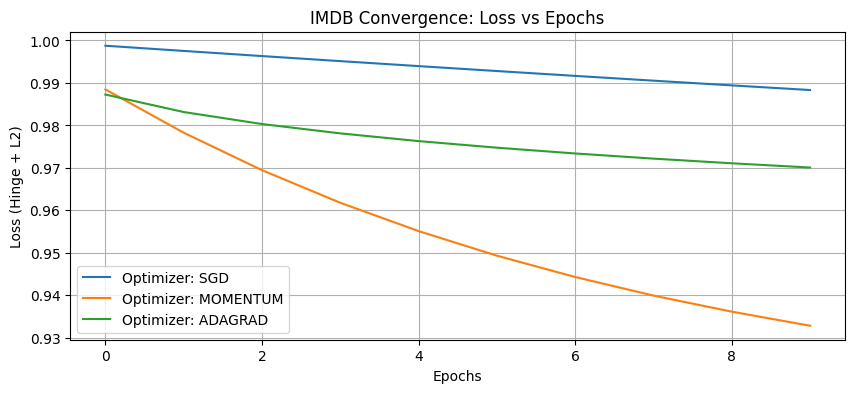

In [16]:
plt.figure(figsize=(10, 4))
for opt in ['sgd', 'momentum', 'adagrad']:
    model = LargeScaleSVM(optimizer=opt, learning_rate=0.001, batch_size=64)
    model.train(X_train_imdb, y_train_imdb, epochs=10) 
    plt.plot(model.history, label=f'Optimizer: {opt.upper()}')

plt.title('IMDB Convergence: Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Hinge + L2)')
plt.legend()
plt.grid(True)
plt.show()

#### TODO - Plot for Higgs dataset

#### TODO - 2 tasks of first part

&#9744; Compare and discuss the effects of optimizer variants and batch sizes. What trends
do you observe?

&#9744; Briefly describe your implementation of each optimizer.

## Random Fourier Features (RFF) for Kernel SVM (25%)

#### TODO

&#9744; Briefly describe your implementation of RFFs.

&#9744; Report how you selected the number of RFFs (minimum 3 different values, at least
one ≥ 100), learning rate, and regularization parameter.

&#9744; Include convergence plots for one optimizer across different RFF sizes.

&#9744; Report classification accuracy/AUC and runtime for each dataset. Discuss how the
number of RFFs affects accuracy and runtime.

&#9744; For IMDB and Higgs, also report performance on different training set sizes (e.g.,
1000, 2000, 3000 samples). Compare your results to using sklearn.svm.SVC (as far as
this is feasible—remark if things break).

In [17]:
class RFFTransformer:
    def __init__(self, n_components=100, sigma=1.0, input_dim=None):
        self.n_components = n_components
        self.sigma = sigma
        self.W = None
        self.b = None
        self.input_dim = input_dim

    def fit(self, X):
    
        d = X.shape[1] if self.input_dim is None else self.input_dim
        
        self.W = (1.0 / self.sigma) * np.random.randn(d, self.n_components)
        
        self.b = np.random.uniform(0, 2 * np.pi, size=self.n_components)
        return self

    def transform(self, X):
        
        projection = np.dot(X, self.W) + self.b
        return np.sqrt(2.0 / self.n_components) * np.cos(projection)

### Classification accuracy/ AUC and runtime for each dataset

#### Toydata_Tiny dataset - RFF for Kernel SVM

In [18]:
rff = RFFTransformer(n_components=150, sigma=1.0)
rff.fit(X_toy_t)
X_rff = rff.transform(X_toy_t)

for opt in ['sgd', 'momentum', 'adagrad']:
    model = LargeScaleSVM(optimizer=opt, batch_size=32)
    model.train(X_rff, y_toy_t)
    
    preds = model.predict(X_rff)
    acc = np.mean(preds == y_toy_t)
    print(f"RFF SVM ({opt}): Accuracy = {acc:.4f}")

RFF SVM (sgd): Accuracy = 0.9850
RFF SVM (momentum): Accuracy = 0.9850
RFF SVM (adagrad): Accuracy = 0.9800


#### Toydata_Large dataset - RFF for Kernel SVM

In [19]:
rff = RFFTransformer(n_components=150, sigma=1.0)
rff.fit(X_toy_l)
X_rff = rff.transform(X_toy_l)

for opt in ['sgd', 'momentum', 'adagrad']:
    model = LargeScaleSVM(optimizer=opt, batch_size=32)
    model.train(X_rff, y_toy_l)
    
    preds = model.predict(X_rff)
    acc = np.mean(preds == y_toy_l)
    print(f"RFF SVM ({opt}): Accuracy = {acc:.4f}")

RFF SVM (sgd): Accuracy = 0.5681
RFF SVM (momentum): Accuracy = 0.5667
RFF SVM (adagrad): Accuracy = 0.5679


#### TODO - IMDB dataset - RFF for Kernel SVM

In [ ]:
# add code here

#### TODO - Higgs dataset - RFF for Kernel SVM

In [ ]:
# add code here

### Compare with sklearn

In [20]:
def compare_with_sklearn(X, y):
    
    start_rff = time.time()
    rff = RFFTransformer(n_components=150)
    rff.fit(X)
    X_rff = rff.transform(X)
    
    my_model = LargeScaleSVM(optimizer='momentum', learning_rate=0.01)
    my_model.train(X_rff, y, epochs=50)
    
    my_preds = my_model.predict(X_rff)
    my_acc = np.mean(my_preds == y)
    print(f"My RFF-SVM: Accuracy = {my_acc:.4f}, Time = {time.time() - start_rff:.2f}s")
    
    start_sk = time.time()
    sk_model = SVC(kernel='rbf') 
    sk_model.fit(X, y)
    
    sk_preds = sk_model.predict(X)
    sk_acc = np.mean(sk_preds == y)
    print(f"Sklearn SVC: Accuracy = {sk_acc:.4f}, Time = {time.time() - start_sk:.2f}s")

#### Compare our implementation with sklearn on Toy datasets

In [21]:
compare_with_sklearn(X_toy_t, y_toy_t)

My RFF-SVM: Accuracy = 1.0000, Time = 0.04s
Sklearn SVC: Accuracy = 0.9950, Time = 0.01s


In [22]:
compare_with_sklearn(X_toy_l, y_toy_l)

My RFF-SVM: Accuracy = 0.5952, Time = 57.82s
Sklearn SVC: Accuracy = 1.0000, Time = 0.48s


#### TODO - Compare our implementation with sklearn on IMDB dataset

In [ ]:
# TODO

#### TODO - Compare our implementation with sklearn on Higgs dataset

In [ ]:
# TODO

## Mini-batch Size and Online vs. Mini-batch Learning (20%)

### Higgs dataset

&#9745; Report training convergence, accuracy/AUC, and runtime for at least three mini-batch
sizes for each optimizer (standard SGD, momentum, Adagrad).

&#9744; Discuss how mini-batch size affects convergence speed, optimization stability, and final
accuracy. Do these effects vary across datasets?

In [ ]:
for b_size in [1, 8, 32, 128, 512]:
    start_time = time.time()
    
    model = LargeScaleSVM(optimizer='momentum', learning_rate=0.001, batch_size=b_size)
    model.train(X_train_higgs, y_train_higgs, epochs=1) 
    
    scores = X_test_higgs.dot(model.w)
    auc_val = roc_auc_score(y_test_higgs, scores)
    
    duration = time.time() - start_time
    print(f"Batch Size {b_size:3} | AUC: {auc_val:.4f} | Time: {duration:.2f}s")